# A Case Study on Continual Learning

This demo notebook presents a selected subset of our code to quickly demonstrate the project and give insights into
our results.

We primarily focus on a simple MLP model architecture and the MNIST dataset, as well as MNIST permutations. For more model architectures and datasets, please refer to the experiment configurations as described in the readme.

## Setup

Before training or models, we set up necessary libraries and resources like datasets.

In [ ]:

# libraries
import sys
import contextlib
from typing import Dict, Optional, List
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# make modules in src/ available
sys.path.insert(0, '../src')

# datasets
from data.mnist_sequential import MNISTSequentialDataModule
from data.mnist_permutations_sequential import MNISTPermutationsSequentialDataModule

# models
from models.mlp import MLP
from models.resnet import ResNet18

# continual learning strategies
from strategies.naive import NaiveStrategy
from strategies.gem import GEMStrategy
from strategies.ewc import EWCStrategy

# metrics
from metrics import CLMetrics

In [3]:
torch.manual_seed(42)
np.random.seed(42)

# configure device
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else ("mps" if torch.backends.mps.is_available() else "cpu")
)
print(f"Using device: {device}")

Using device: cuda


### Datasets

For this project we implemented five different datasets in total, but for this demo we will only focus on MNIST and MNIST permutations. The MNIST dataset is split into three subsets as tasks, and the permuted MNIST dataset uses different pixel permutations per task. The split MNIST dataset has disjoint label spaces for each task while each task from permuted MNIST has an identical label space.

Loading MNIST dataset

--- TASK SUBSETS ---
Task A (labels [0, 1, 2, 3]): 24754 train, 4157 test
Task B (labels [4, 5, 6]): 17181 train, 2832 test
Task C (labels [7, 8, 9]): 18065 train, 3011 test


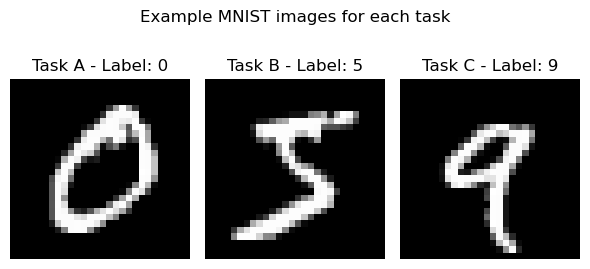

In [8]:
print("Loading MNIST dataset")
mnist_datamodule = MNISTSequentialDataModule()
mnist_datamodule.setup()

# plot example images
fig, axes = plt.subplots(1, 3, figsize=(6, 3))
fig.suptitle("Example MNIST images for each task")
for i, task in enumerate(["A", "B", "C"]):
    subset = getattr(mnist_datamodule, f"train_subset_{task.lower()}")
    image, label = subset[0]
    axes[i].imshow(image.squeeze(), cmap="gray")
    axes[i].set_title(f"Task {task} - Label: {label}")
    axes[i].axis("off")
plt.tight_layout()
plt.show()

Loading MNIST permutations dataset

--- TASK PERMUTATIONS ---
Task A: 60000 train, 10000 test
Task B: 60000 train, 10000 test
Task C: 60000 train, 10000 test
Task D: 60000 train, 10000 test
Task E: 60000 train, 10000 test


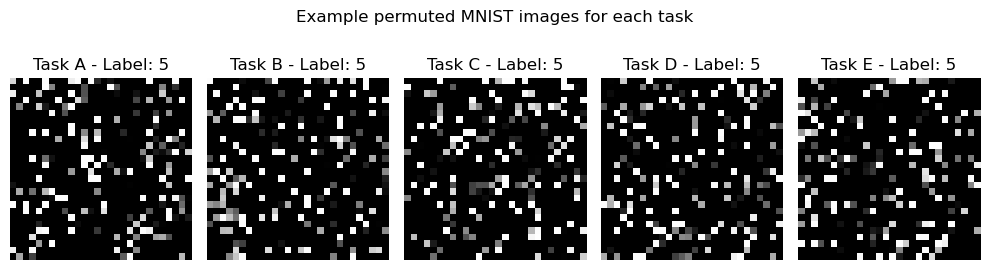

In [5]:
print("Loading MNIST permutations dataset")
mnist_permutations_datamodule = MNISTPermutationsSequentialDataModule()
mnist_permutations_datamodule.setup()

# plot example images
fig, axes = plt.subplots(1, 5, figsize=(10, 3))
fig.suptitle("Example permuted MNIST images for each task")
for i, task in enumerate(["A", "B", "C", "D", "E"]):
    subset = getattr(mnist_permutations_datamodule, f"train_perm_{task.lower()}")
    image, label = subset[0]
    axes[i].imshow(image.squeeze(), cmap="gray")
    axes[i].set_title(f"Task {task} - Label: {label}")
    axes[i].axis("off")
plt.tight_layout()
plt.show()

### Model

In this demo we demontrate catastrophic forgetting and continual learning strategies with a simple MLP model. The additional, a simple CNN and a ResNet18 reimplementation are not showcased in this notebook (we will touch ResNet briefly near the end).

In [5]:
model = MLP(input_size=784, hidden_sizes=[256, 128], num_classes=10, dropout=0.0).to(device)
print(f"\nModel:\n{model}")


Model:
MLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (net): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.0, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Linear(in_features=128, out_features=10, bias=True)
  )
)


### Trainer

For training we use a reusable trainer class which trains the model on multiple sequential tasks. Additionally the trainer uses strategy hooks with a shared interface for applying a continual learning strategy:

- `before_task()`
- `after_task()`
- `after_backward()`
- `compute_loss()`

In [6]:
# slightly modified version of the SequentialTrainer from src.training.sequential
class SequentialTrainer:
    def __init__(
        self, 
        model, 
        optimizer, 
        strategy,
        device, 
        metrics=None,
        max_epochs_per_task=3
    ):
        # Keep a reference to the unwrapped model for strategy hooks and checkpointing.
        # DataParallel wraps the model, but strategies and save_model always need raw weights.
        self._raw_model = model
        self.optimizer = optimizer
        self.strategy = strategy
        self.device = device
        self.metrics = metrics
        self.max_epochs_per_task = max_epochs_per_task
        self.criterion = nn.CrossEntropyLoss()
        self.num_tasks = None

        # Wrap with DataParallel when multiple CUDA GPUs are available.
        # NOTE: for small models (MLP) this rarely helps due to scatter/gather overhead.
        #       It pays off for ResNet+ with large batch sizes.
        num_gpus = torch.cuda.device_count()
        if num_gpus > 1:
            self.model = nn.DataParallel(model)
        else:
            self.model = model


        
    def train_one_epoch(self, task_id: str, train_loader):
        """Train for one epoch.
        
        Args:
            task_id: Current task identifier
            train_loader: DataLoader for this epoch
        """
        self.model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        for batch_idx, (images, targets) in enumerate(train_loader):
            images = images.to(self.device)
            targets = targets.to(self.device)
            
            self.optimizer.zero_grad()
            outputs = self.model(images)
            # Use strategy to compute loss (pass unwrapped model for parameter access)
            loss = self.strategy.compute_loss(self._raw_model, images, outputs, targets, task_id)
            loss.backward()
            self.strategy.after_backward(self._raw_model, task_id)
            self.optimizer.step()
            
            running_loss += loss.item() * images.size(0)
            _, preds = outputs.max(1)
            correct += (preds == targets).sum().item()
            total += targets.size(0)
                
        return running_loss / total, correct / total
    
    def evaluate(self, test_loader):
        """Evaluate on test set."""
        self.model.eval()
        running_loss = 0.0
        correct = 0
        total = 0
        
        with torch.no_grad():
            for images, targets in test_loader:
                images = images.to(self.device)
                targets = targets.to(self.device)
                
                outputs = self.model(images)
                loss = self.criterion(outputs, targets)
                
                running_loss += loss.item() * images.size(0)
                _, preds = outputs.max(1)
                correct += (preds == targets).sum().item()
                total += targets.size(0)
                
        return running_loss / total, correct / total
    
    def evaluate_on_all_tasks(self, test_loaders: Dict):
        """Evaluate on all tasks after training on one task.
        
        Fills a complete row of Matrix R: runs evaluation on all test sets
        after training on the current task, and records results in metrics.
        This matrix is later used for BWT and ACC computation and could be
        used for further metrics (e.g. FWT) in the future.
        
        Args:
            test_loaders: Dictionary mapping task_id -> test DataLoader
        """
        if self.metrics is None:
            return
        
        for test_task, test_loader in test_loaders.items():
            loss, accuracy = self.evaluate(test_loader)
            # Store in metrics using the pre-computed accuracy value
            self.metrics.record_accuracy_value(test_task, accuracy)
            print(f"  Task {test_task}: loss={loss:.4f}, accuracy={accuracy:.4f}")

    def train_task(self, task: str, train_loader, test_loaders: Dict):
        """Train on one task and evaluate on all tasks.
        
        Args:
            task: Task identifier
            train_loader: Training DataLoader
            test_loaders: Dictionary mapping task_id -> test DataLoader
        """
        # Initialize metrics for this task
        if self.metrics is not None:
            self.metrics.reset(task)
        
        # Call strategy hook before task (always pass the unwrapped model)
        self.strategy.before_task(self._raw_model, task, self.num_tasks)

        print(f"Training on task {task}:")
        
        for epoch in range(1, self.max_epochs_per_task + 1):
            # Train on current task
            train_loss, train_acc = self.train_one_epoch(task, train_loader)
            
            # Evaluate on current task
            test_loss, test_acc = self.evaluate(test_loaders[task])
        
        # Call strategy hook after task (always pass the unwrapped model)
        self.strategy.after_task(self._raw_model, task, train_loader)
        
        # Evaluate on all tasks to fill one row of Matrix R
        self.evaluate_on_all_tasks(test_loaders)
    
    def fit(self, datamodule, tasks: Optional[List[str]] = None):
        """Train through all tasks sequentially."""
        if tasks is None:
            tasks = ['A', 'B', 'C']
        self.num_tasks = len(tasks)

        test_loaders = {task: datamodule.get_test_loader(task) for task in tasks}
        
        for task in tasks:
            train_loader = datamodule.get_train_loader(task)
            self.train_task(task, train_loader, test_loaders)
        

## Naive Training

Firstly we train our models using the naive strategy. This strategy does not contain any mitigations for catastrophic forgetting, so we can expect suboptimal performance on the early tasks.

In [7]:
# setup strategy
naive_strategy = NaiveStrategy()

# setup optimizer
optimizer_mnist_naive = torch.optim.Adam(
    model.parameters(), lr=0.001, betas=[0.9, 0.999], eps=1.0e-8, weight_decay=0.0
)

### MNIST

We train our MLP seuquentially on the MNIST dataset tasks.

In [8]:
# train MLP on MNIST using the naive strategy
mnist_naive_trainer = SequentialTrainer(
    model,
    optimizer_mnist_naive,
    naive_strategy,
    device,
    metrics=CLMetrics(),
    max_epochs_per_task=3
)
mnist_naive_trainer.fit(mnist_datamodule, tasks=["A", "B", "C"])

Training on task A:
  Task A: loss=0.0302, accuracy=0.9901
  Task B: loss=11.8354, accuracy=0.0000
  Task C: loss=10.5074, accuracy=0.0000
Training on task B:
  Task A: loss=14.1725, accuracy=0.0000
  Task B: loss=0.0367, accuracy=0.9883
  Task C: loss=20.1313, accuracy=0.0000
Training on task C:
  Task A: loss=14.6142, accuracy=0.0000
  Task B: loss=9.8326, accuracy=0.0000
  Task C: loss=0.0475, accuracy=0.9827


In [9]:
# print metrics for MNIST
if mnist_naive_trainer.metrics is not None:
    mnist_naive_trainer.metrics.print_summary()


CONTINUAL LEARNING METRICS

Matrix R (accuracy on task j after training on task i):
------------------------------------------------------------
Trained→Test	A	B	C
A		0.9901	0.0000	0.0000	
B		0.0000	0.9883	0.0000	
C		0.0000	0.0000	0.9827	

Backward Transfer (BWT): -0.9892
Average Accuracy (ACC):  0.3276


We can observe that with each newly trained tasks the previous tasks will be forgotten and their performance degrades heavily. Consequently we have a backward transfer of almost $-1$.

### MNIST Permutations

We repeat this for the "easier" MNIST permutations and can observe a similar result, although less severe.

In [10]:
# setup new model and optimizer
model = MLP(
    input_size=784, hidden_sizes=[256, 128], num_classes=10, dropout=0.0
).to(device)
optimizer = torch.optim.Adam(
    model.parameters(), lr=0.001, betas=[0.9, 0.999], eps=1.0e-8, weight_decay=0.0
)

# train MLP on permuted MNIST using the naive strategy
mnist_permutations_naive_trainer = SequentialTrainer(
    model,
    optimizer,
    naive_strategy,
    device,
    metrics=CLMetrics(),
    max_epochs_per_task=3,
)
mnist_permutations_naive_trainer.fit(
    mnist_permutations_datamodule, tasks=["A", "B", "C", "D", "E"]
)

Training on task A:
  Task A: loss=0.0910, accuracy=0.9728
  Task B: loss=3.8504, accuracy=0.1320
  Task C: loss=4.1757, accuracy=0.1600
  Task D: loss=5.7595, accuracy=0.0920
  Task E: loss=5.5099, accuracy=0.0803
Training on task B:
  Task A: loss=0.3104, accuracy=0.9069
  Task B: loss=0.0817, accuracy=0.9731
  Task C: loss=5.3649, accuracy=0.1586
  Task D: loss=7.1592, accuracy=0.1062
  Task E: loss=6.7846, accuracy=0.0778
Training on task C:
  Task A: loss=0.8234, accuracy=0.7295
  Task B: loss=0.3246, accuracy=0.8864
  Task C: loss=0.0980, accuracy=0.9711
  Task D: loss=6.4143, accuracy=0.0966
  Task E: loss=4.7844, accuracy=0.1171
Training on task D:
  Task A: loss=1.5617, accuracy=0.5336
  Task B: loss=0.6359, accuracy=0.7713
  Task C: loss=0.2269, accuracy=0.9313
  Task D: loss=0.0903, accuracy=0.9730
  Task E: loss=3.5685, accuracy=0.1535
Training on task E:
  Task A: loss=3.2919, accuracy=0.2480
  Task B: loss=1.3557, accuracy=0.5824
  Task C: loss=0.6361, accuracy=0.7902
  T

In [11]:
# print metrics for MNIST permutations
if mnist_permutations_naive_trainer.metrics is not None:
    mnist_permutations_naive_trainer.metrics.print_summary()


CONTINUAL LEARNING METRICS

Matrix R (accuracy on task j after training on task i):
------------------------------------------------------------
Trained→Test	A	B	C	D	E
A		0.9728	0.1320	0.1600	0.0920	0.0803	
B		0.9069	0.9731	0.1586	0.1062	0.0778	
C		0.7295	0.8864	0.9711	0.0966	0.1171	
D		0.5336	0.7713	0.9313	0.9730	0.1535	
E		0.2480	0.5824	0.7902	0.9219	0.9767	

Backward Transfer (BWT): -0.3369
Average Accuracy (ACC):  0.7038


## Gradient Episodic Memory (GEM)

GEM is a replay-based continual learning strategy. For using GEM, we only need to pass the `GEMStrategy` to our sequential trainer.

### MNIST

Similar to the naive strategy we start with split MNIST.

In [12]:
# setup strategy
gem_strategy = GEMStrategy(mem_size=1024, margin=0.5)

# setup new model and optimizer
model = MLP(
    input_size=784, hidden_sizes=[256, 128], num_classes=10, dropout=0.0
).to(device)
optimizer = torch.optim.Adam(
    model.parameters(), lr=0.001, betas=[0.9, 0.999], eps=1.0e-8, weight_decay=0.0
)

# train MLP on MNIST using the GEM strategy
mnist_gem_trainer = SequentialTrainer(
    model,
    optimizer,
    gem_strategy,
    device,
    metrics=CLMetrics(),
    max_epochs_per_task=3,
)
mnist_gem_trainer.fit(mnist_datamodule, tasks=["A", "B", "C"])

Training on task A:
  Task A: loss=0.0267, accuracy=0.9935
  Task B: loss=11.6049, accuracy=0.0000
  Task C: loss=11.1326, accuracy=0.0000
Training on task B:
  Task A: loss=0.5254, accuracy=0.9019
  Task B: loss=0.0372, accuracy=0.9883
  Task C: loss=24.9038, accuracy=0.0000
Training on task C:
  Task A: loss=0.8226, accuracy=0.8761
  Task B: loss=0.5673, accuracy=0.8778
  Task C: loss=0.0476, accuracy=0.9821


In [13]:
if mnist_gem_trainer.metrics is not None:
    mnist_gem_trainer.metrics.print_summary()


CONTINUAL LEARNING METRICS

Matrix R (accuracy on task j after training on task i):
------------------------------------------------------------
Trained→Test	A	B	C
A		0.9935	0.0000	0.0000	
B		0.9019	0.9883	0.0000	
C		0.8761	0.8778	0.9821	

Backward Transfer (BWT): -0.1140
Average Accuracy (ACC):  0.9120


With GEM we achieve and retain an accuracy of more than $0.85$ on all tasks. The backward transfer is only $-0.13$ (compared to $-0.99$ without GEM). We can observe GEM limits catastrophic forgetting.

### MNIST Permutations

We continue again with the MNIST permutations. We can observe a similar performance improvement, with a negative backward transfer of only $-0.04$.

In [14]:
# setup new model and optimizer
model = MLP(
    input_size=784, hidden_sizes=[256, 128], num_classes=10, dropout=0.0
).to(device)
optimizer = torch.optim.Adam(
    model.parameters(), lr=0.001, betas=[0.9, 0.999], eps=1.0e-8, weight_decay=0.0
)

# train MLP on permuted MNIST using the GEM strategy
mnist_permutations_gem_trainer = SequentialTrainer(
    model,
    optimizer,
    gem_strategy,
    device,
    metrics=CLMetrics(),
    max_epochs_per_task=3,
)
mnist_permutations_gem_trainer.fit(
    mnist_permutations_datamodule, tasks=["A", "B", "C", "D", "E"]
)

Training on task A:
  Task A: loss=0.0913, accuracy=0.9724
  Task B: loss=3.5902, accuracy=0.1187
  Task C: loss=4.1124, accuracy=0.1605
  Task D: loss=5.7558, accuracy=0.0963
  Task E: loss=5.2155, accuracy=0.0683
Training on task B:
  Task A: loss=0.1304, accuracy=0.9638
  Task B: loss=0.0815, accuracy=0.9758
  Task C: loss=5.6898, accuracy=0.1322
  Task D: loss=7.0655, accuracy=0.1333
  Task E: loss=7.1991, accuracy=0.1008
Training on task C:
  Task A: loss=0.2555, accuracy=0.9357
  Task B: loss=0.1338, accuracy=0.9626
  Task C: loss=0.0870, accuracy=0.9730
  Task D: loss=5.2407, accuracy=0.0749
  Task E: loss=4.5703, accuracy=0.1455
Training on task D:
  Task A: loss=0.4017, accuracy=0.9178
  Task B: loss=0.2018, accuracy=0.9491
  Task C: loss=0.1435, accuracy=0.9602
  Task D: loss=0.0922, accuracy=0.9714
  Task E: loss=4.1819, accuracy=0.1594
Training on task E:
  Task A: loss=0.5262, accuracy=0.9055
  Task B: loss=0.3419, accuracy=0.9252
  Task C: loss=0.2242, accuracy=0.9429
  T

In [15]:
if mnist_permutations_gem_trainer.metrics is not None:
    mnist_permutations_gem_trainer.metrics.print_summary()


CONTINUAL LEARNING METRICS

Matrix R (accuracy on task j after training on task i):
------------------------------------------------------------
Trained→Test	A	B	C	D	E
A		0.9724	0.1187	0.1605	0.0963	0.0683	
B		0.9638	0.9758	0.1322	0.1333	0.1008	
C		0.9357	0.9626	0.9730	0.0749	0.1455	
D		0.9178	0.9491	0.9602	0.9714	0.1594	
E		0.9055	0.9252	0.9429	0.9605	0.9747	

Backward Transfer (BWT): -0.0396
Average Accuracy (ACC):  0.9418


## Elastic Weight Consolidation (EWC)

EWC is a regularization-based continual learning strategy. For using EWC, we only need to pass the `EWCStrategy` to our sequential trainer. Our evaluation method is equal to the GEM strategy.

### MNIST

In contrast to GEM, EWC only leads to a negligible performance improvement compared to the naive strategy, so EWC does seem to have a problem with disjoint label spaces present in out split MNIST experiment.

In [16]:
# setup strategy
ewc_strategy = EWCStrategy(reg_param=10000)

# setup new model and optimizer
model = MLP(
    input_size=784, hidden_sizes=[256, 128], num_classes=10, dropout=0.0
).to(device)
optimizer = torch.optim.Adam(
    model.parameters(), lr=0.001, betas=[0.9, 0.999], eps=1.0e-8, weight_decay=0.0
)

# train MLP on MNIST using the EWC strategy
mnist_ewc_trainer = SequentialTrainer(
    model,
    optimizer,
    ewc_strategy,
    device,
    metrics=CLMetrics(),
    max_epochs_per_task=3,
)
mnist_ewc_trainer.fit(mnist_datamodule, tasks=["A", "B", "C"])

Training on task A:
  Task A: loss=0.0272, accuracy=0.9913
  Task B: loss=10.7558, accuracy=0.0000
  Task C: loss=9.1603, accuracy=0.0000
Training on task B:
  Task A: loss=13.0713, accuracy=0.0000
  Task B: loss=0.0377, accuracy=0.9873
  Task C: loss=17.7947, accuracy=0.0000
Training on task C:
  Task A: loss=11.7376, accuracy=0.0000
  Task B: loss=7.4925, accuracy=0.0780
  Task C: loss=0.0496, accuracy=0.9824


In [17]:
if mnist_ewc_trainer.metrics is not None:
    mnist_ewc_trainer.metrics.print_summary()


CONTINUAL LEARNING METRICS

Matrix R (accuracy on task j after training on task i):
------------------------------------------------------------
Trained→Test	A	B	C
A		0.9913	0.0000	0.0000	
B		0.0000	0.9873	0.0000	
C		0.0000	0.0780	0.9824	

Backward Transfer (BWT): -0.9503
Average Accuracy (ACC):  0.3535


### MNIST Permutations

For the MNIST permutation tasks with identical label spaces EWC performs much better.

In [18]:
# setup new model and optimizer
model = MLP(
    input_size=784, hidden_sizes=[256, 128], num_classes=10, dropout=0.0
).to(device)
optimizer = torch.optim.Adam(
    model.parameters(), lr=0.001, betas=[0.9, 0.999], eps=1.0e-8, weight_decay=0.0
)

# train MLP on permuted MNIST using the EWC strategy
mnist_permutations_ewc_trainer = SequentialTrainer(
    model,
    optimizer,
    ewc_strategy,
    device,
    metrics=CLMetrics(),
    max_epochs_per_task=3,
)
mnist_permutations_ewc_trainer.fit(
    mnist_permutations_datamodule, tasks=["A", "B", "C", "D", "E"]
)

Training on task A:
  Task A: loss=0.0767, accuracy=0.9758
  Task B: loss=3.7106, accuracy=0.1320
  Task C: loss=4.4480, accuracy=0.1870
  Task D: loss=5.5876, accuracy=0.0786
  Task E: loss=6.3511, accuracy=0.0512
Training on task B:
  Task A: loss=0.0843, accuracy=0.9722
  Task B: loss=0.1127, accuracy=0.9644
  Task C: loss=4.8169, accuracy=0.1858
  Task D: loss=5.9042, accuracy=0.0766
  Task E: loss=6.8664, accuracy=0.0450
Training on task C:
  Task A: loss=0.1287, accuracy=0.9600
  Task B: loss=0.1172, accuracy=0.9622
  Task C: loss=0.0975, accuracy=0.9677
  Task D: loss=6.5272, accuracy=0.0612
  Task E: loss=6.5519, accuracy=0.0674
Training on task D:
  Task A: loss=0.2343, accuracy=0.9276
  Task B: loss=0.2599, accuracy=0.9132
  Task C: loss=0.0986, accuracy=0.9679
  Task D: loss=0.0978, accuracy=0.9695
  Task E: loss=5.2750, accuracy=0.0769
Training on task E:
  Task A: loss=0.5025, accuracy=0.8327
  Task B: loss=0.4543, accuracy=0.8510
  Task C: loss=0.1702, accuracy=0.9486
  T

In [19]:
if mnist_permutations_ewc_trainer.metrics is not None:
    mnist_permutations_ewc_trainer.metrics.print_summary()


CONTINUAL LEARNING METRICS

Matrix R (accuracy on task j after training on task i):
------------------------------------------------------------
Trained→Test	A	B	C	D	E
A		0.9758	0.1320	0.1870	0.0786	0.0512	
B		0.9722	0.9644	0.1858	0.0766	0.0450	
C		0.9600	0.9622	0.9677	0.0612	0.0674	
D		0.9276	0.9132	0.9679	0.9695	0.0769	
E		0.8327	0.8510	0.9486	0.9674	0.9646	

Backward Transfer (BWT): -0.0694
Average Accuracy (ACC):  0.9129


## ResNet

Finally we take a short look on applying our continual learning strategies to a more complex model architecture, a reimplementation of ResNet18 using the MNIST permutations experiment to see how the behaviour is changed by the model architecture.

In [20]:
model = ResNet18(num_classes=10, grayscale=True).to(device)
print(f"\nModel:\n{model}")


Model:
ResNet18(
  (conv1): Sequential(
    (0): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (conv2): Sequential(
    (0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (1): ResidualBlock(
      (weightLayer1): Sequential(
        (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (relu): ReLU()
      (weightLayer2): Sequential(
        (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (downsample): Sequential()
    )
    (2): ResidualBlock(
      (weightLayer1): Sequential(
        (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNo

### Naive Strategy

We can observe that catastrophic forgetting is a bit more severe for ResNet compared to the MLP.

In [21]:
# setup optimizer
optimizer = torch.optim.Adam(
    model.parameters(), lr=0.001, betas=[0.9, 0.999], eps=1.0e-8, weight_decay=0.0
)

# train MLP on permuted MNIST using the naive strategy
mnist_permutations_naive_trainer = SequentialTrainer(
    model,
    optimizer,
    naive_strategy,
    device,
    metrics=CLMetrics(),
    max_epochs_per_task=3,
)
with contextlib.redirect_stdout(None):
    mnist_permutations_naive_trainer.fit(
        mnist_permutations_datamodule, tasks=["A", "B", "C", "D", "E"]
    )

if mnist_permutations_naive_trainer.metrics is not None:
    mnist_permutations_naive_trainer.metrics.print_summary()


CONTINUAL LEARNING METRICS

Matrix R (accuracy on task j after training on task i):
------------------------------------------------------------
Trained→Test	A	B	C	D	E
A		0.9553	0.1366	0.1482	0.1001	0.0910	
B		0.3793	0.9588	0.1394	0.1224	0.0820	
C		0.1862	0.4792	0.9668	0.1330	0.1353	
D		0.1269	0.1860	0.4111	0.9663	0.1089	
E		0.0950	0.1339	0.2073	0.5001	0.9696	

Backward Transfer (BWT): -0.7277
Average Accuracy (ACC):  0.3812


### GEM

This is also the case for GEM. The ACC is now only $0.825$ instead of $0.94$, and BWT is $-1.168$ insead of $-0.04$ for the MLP.

In [22]:
# setup new model and optimizer
model = ResNet18(num_classes=10, grayscale=True).to(device)
optimizer = torch.optim.Adam(
    model.parameters(), lr=0.001, betas=[0.9, 0.999], eps=1.0e-8, weight_decay=0.0
)

# train MLP on permuted MNIST using the GEM strategy
mnist_permutations_gem_trainer = SequentialTrainer(
    model,
    optimizer,
    gem_strategy,
    device,
    metrics=CLMetrics(),
    max_epochs_per_task=3,
)
with contextlib.redirect_stdout(None):
    mnist_permutations_gem_trainer.fit(
        mnist_permutations_datamodule, tasks=["A", "B", "C", "D", "E"]
    )

if mnist_permutations_gem_trainer.metrics is not None:
    mnist_permutations_gem_trainer.metrics.print_summary()


CONTINUAL LEARNING METRICS

Matrix R (accuracy on task j after training on task i):
------------------------------------------------------------
Trained→Test	A	B	C	D	E
A		0.9614	0.1077	0.0791	0.1001	0.1184	
B		0.8295	0.9573	0.1133	0.1028	0.0987	
C		0.7876	0.8322	0.9598	0.1204	0.1296	
D		0.7661	0.7883	0.8786	0.9607	0.1579	
E		0.7595	0.7563	0.7997	0.8511	0.9599	

Backward Transfer (BWT): -0.1682
Average Accuracy (ACC):  0.8253


### EWC

When using ResNet, the performance of EWC becomes significantly worse compared to the MLP results and is not feasible anymore for continual learning.

In [23]:
# setup new model and optimizer
model = ResNet18(num_classes=10, grayscale=True).to(device)
optimizer = torch.optim.Adam(
    model.parameters(), lr=0.001, betas=[0.9, 0.999], eps=1.0e-8, weight_decay=0.0
)

# train MLP on permuted MNIST using the EWC strategy
mnist_permutations_ewc_trainer = SequentialTrainer(
    model,
    optimizer,
    ewc_strategy,
    device,
    metrics=CLMetrics(),
    max_epochs_per_task=3,
)
with contextlib.redirect_stdout(None):
    mnist_permutations_ewc_trainer.fit(
        mnist_permutations_datamodule, tasks=["A", "B", "C", "D", "E"]
    )

if mnist_permutations_ewc_trainer.metrics is not None:
    mnist_permutations_ewc_trainer.metrics.print_summary()


CONTINUAL LEARNING METRICS

Matrix R (accuracy on task j after training on task i):
------------------------------------------------------------
Trained→Test	A	B	C	D	E
A		0.9392	0.1148	0.0944	0.1233	0.0845	
B		0.3243	0.9287	0.1250	0.1824	0.1183	
C		0.2238	0.3121	0.8783	0.1089	0.0981	
D		0.1019	0.2112	0.1788	0.9228	0.1210	
E		0.1070	0.1196	0.1868	0.3266	0.9074	

Backward Transfer (BWT): -0.7322
Average Accuracy (ACC):  0.3295


## Conclusion

This notebook demonstrates the key findings of our case study in practice. We observed catastrophic forgetting when training multiple tasks sequentially without any countermeasures.

In our experiments for limiting catastrophic forgetting, GEM performs well in almost all cases while the performance of EWC degrades especially with disjoint label spaces and more complex model architectures.

For additional experiments, models and datasets one can refer to the pipeline stated in the `README.md`.